# Análisis de reseñas de una institución EdTech

## Contexto

Una institución **EdTech que ofrece cursos de inglés en modalidad online** recibe reseñas públicas en Google en las que los usuarios califican su experiencia mediante estrellas y, en la mayoría de los casos, añaden un comentario escrito. Estas reseñas constituyen una fuente de información útil para conocer cómo está siendo percibido el servicio desde la perspectiva del estudiante.

El análisis combina información **estructurada** como la cantidad de estrellas y la existencia de una respuesta por parte de la institución con información **no estructurada**, representada por el texto libre de los comentarios. De esta manera, no solo interesa conocer si la valoración general es positiva o negativa, sino también identificar **qué aspectos de la experiencia educativa aparecen con mayor frecuencia**, qué temas emergen de las opiniones y qué señales podrían requerir atención.

Desde una perspectiva de negocio, los resultados pueden apoyar la gestión de la experiencia del estudiante, la reputación digital y la priorización de acciones de mejora.

## Objetivo general

Analizar las reseñas de Google de una institución EdTech de enseñanza de inglés para conocer la percepción de los usuarios, identificar los principales atributos asociados a su experiencia, reconocer temas recurrentes y explorar el sentimiento expresado en los comentarios.

## Objetivos específicos

- Revisar la estructura y calidad de la base de datos.
- Analizar la distribución de estrellas, la presencia de comentarios y la gestión de respuestas.
- Preparar los comentarios para su análisis mediante técnicas de procesamiento de texto.
- Identificar palabras y expresiones frecuentes dentro de las reseñas.
- Extraer temas latentes mediante un modelo no supervisado NMF.
- Clasificar el sentimiento de los comentarios con un modelo preentrenado y contrastarlo de manera referencial con las estrellas.
- Formular conclusiones y recomendaciones sustentadas en los resultados obtenidos.

## Flujo del análisis

El notebook sigue una secuencia que conecta el análisis descriptivo con la minería de texto:

**Preparación del entorno → carga de datos → revisión de calidad → análisis descriptivo → preparación textual → términos frecuentes → modelado de temas NMF → análisis de sentimiento → conclusiones y recomendaciones.**

> **Nota metodológica:** las reseñas de Google corresponden a usuarios que decidieron publicar voluntariamente su opinión. Por ello, los resultados describen la muestra disponible, pero no deben interpretarse automáticamente como una medición representativa de todos los estudiantes de la institución.

## 1. Preparación del entorno

Se cargan las librerías necesarias para manipulación de datos, limpieza de texto, visualización, minería de texto, modelado no supervisado y evaluación del análisis de sentimiento.

In [43]:
# Instala las librerías usadas para limpiar texto y crear nubes de palabras.
%pip install -q spacy unidecode wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
# Manejo de archivos y datos
from pathlib import Path
import pandas as pd
import numpy as np

# Limpieza de texto
import re
from unidecode import unidecode
from spacy.lang.es.stop_words import STOP_WORDS as STOPWORDS_ES
from spacy.lang.en.stop_words import STOP_WORDS as STOPWORDS_EN

# Gráficos
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Minería de texto y modelamiento no supervisado
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF

# Evaluación del análisis de sentimiento
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Muestra más texto dentro de las tablas sin recortarlo demasiado.
pd.set_option("display.max_colwidth", 120)

## 2. Carga de la base de datos

La información de las reseñas se encuentra almacenada en un archivo Excel.

In [45]:
ruta_excel = "../../2data_local_me/data_edtech_review_sentiment_intelligence/reviews_institucion_edtech.xlsx"

In [46]:
# Lee la hoja "Reviews" del archivo Excel y la guarda como DataFrame.
df_reviews = pd.read_excel(ruta_excel, sheet_name="Reviews")

# Por criterios de privacidad, no se muestran nombres de usuarios, comentarios completos ni respuestas publicadas por el propietario.
# Estas variables se mantienen en el DataFrame y se utilizarán posteriormente en los análisis correspondientes.

columnas_a_visualizar = ["ID_REVIEW", "ESTRELLAS", "TIEMPO_REVIEW", "TIPO_RESEÑA", 
                         "TIENE_COMENTARIO", "TIENE_RESPUESTA_PROPIETARIO", "ESTADO_RESPUESTA"]

# Muestra las primeras cinco filas para comprobar que los datos se cargaron correctamente.
df_reviews[columnas_a_visualizar].head()

,ID_REVIEW,ESTRELLAS,TIEMPO_REVIEW,TIPO_RESEÑA,TIENE_COMENTARIO,TIENE_RESPUESTA_PROPIETARIO,ESTADO_RESPUESTA
0,1,1,Hace un mes,Con comentario,1,0,Sin respuesta
1,2,5,Hace 3 meses,Con comentario,1,0,Sin respuesta
2,3,5,Hace 5 meses,Con comentario,1,0,Sin respuesta
3,4,5,Hace 7 meses,Con comentario,1,0,Sin respuesta
4,5,5,Hace 7 meses,Con comentario,1,0,Sin respuesta


### 2.1. Diccionario de variables

| Variable | Descripción |
|---|---|
| `ID_REVIEW` | Identificador único de la reseña. |
| `NOMBRE_USUARIO` | Nombre mostrado por el usuario. |
| `ESTRELLAS` | Calificación otorgada, de 1 a 5. |
| `TIEMPO_REVIEW` | Antigüedad referencial de la reseña. |
| `TIPO_RESEÑA` | Indica si contiene texto o solo estrellas. |
| `TIENE_COMENTARIO` | Variable binaria: 1 = sí y 0 = no. |
| `COMENTARIO` | Texto escrito por el usuario. |
| `TIENE_RESPUESTA_PROPIETARIO` | Variable binaria: 1 = respondida y 0 = no respondida. |
| `ESTADO_RESPUESTA` | Estado textual de la respuesta. |
| `RESPUESTA_PROPIETARIO` | Texto publicado por la institución. |

## 3. Revisión de la estructura y calidad de los datos

Antes de analizar las reseñas, se revisan las dimensiones de la base, los tipos de datos, los valores vacíos y la existencia de registros duplicados. Esta etapa permite determinar qué variables pueden utilizarse directamente y cuáles requieren un tratamiento particular.

In [47]:
# Muestra la cantidad de filas y columnas.
filas, columnas = df_reviews.shape
print(f"La base contiene {filas} filas y {columnas} columnas.")

La base contiene 156 filas y 10 columnas.


In [48]:
# Muestra los tipos de datos y la cantidad de valores disponibles por columna.
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   ID_REVIEW                    156 non-null    int64 
 1   NOMBRE_USUARIO               156 non-null    object
 2   ESTRELLAS                    156 non-null    int64 
 3   TIEMPO_REVIEW                156 non-null    object
 4   TIPO_RESEÑA                  156 non-null    object
 5   TIENE_COMENTARIO             156 non-null    int64 
 6   COMENTARIO                   147 non-null    object
 7   TIENE_RESPUESTA_PROPIETARIO  156 non-null    int64 
 8   ESTADO_RESPUESTA             156 non-null    object
 9   RESPUESTA_PROPIETARIO        125 non-null    object
dtypes: int64(4), object(6)
memory usage: 12.3+ KB


In [49]:
# Resume valores vacíos, valores únicos y tipos de datos.
resumen_calidad = pd.DataFrame({
    "TIPO_DATO": df_reviews.dtypes.astype(str),
    "VALORES_VACÍOS": df_reviews.isna().sum(),
    "VALORES_ÚNICOS": df_reviews.nunique()
})

resumen_calidad

,TIPO_DATO,VALORES_VACÍOS,VALORES_ÚNICOS
ID_REVIEW,int64,0,156
NOMBRE_USUARIO,object,0,156
ESTRELLAS,int64,0,5
TIEMPO_REVIEW,object,0,11
TIPO_RESEÑA,object,0,2
TIENE_COMENTARIO,int64,0,2
COMENTARIO,object,9,147
TIENE_RESPUESTA_PROPIETARIO,int64,0,2
ESTADO_RESPUESTA,object,0,2
RESPUESTA_PROPIETARIO,object,31,125


In [50]:
# Cuenta filas completamente duplicadas.
duplicados = df_reviews.duplicated().sum()
print(f"Registros duplicados: {duplicados}")

Registros duplicados: 0


### Interpretación

La base contiene **156 reseñas y 10 variables** y no presenta registros completamente duplicados. Los valores vacíos se concentran en `COMENTARIO` (**9 casos**) y `RESPUESTA_PROPIETARIO` (**31 casos**).

Estas ausencias son coherentes con la propia estructura del problema: algunas personas calificaron únicamente con estrellas y algunas reseñas no recibieron una respuesta de la institución. Por esta razón, **no corresponde eliminar automáticamente esos registros**, ya que la ausencia de comentario o de respuesta también aporta información relevante para el análisis.

Para la minería de texto se trabajará únicamente con las **147 reseñas que sí contienen comentario**, mientras que el análisis descriptivo seguirá utilizando las 156 observaciones.

## 4. Análisis descriptivo de las reseñas

Esta sección establece una primera lectura de la experiencia reportada por los usuarios. Se analiza la distribución de estrellas, la proporción de reseñas con comentario, la gestión de respuestas y la extensión de los textos antes de pasar al procesamiento de lenguaje natural.

### 4.1. Distribución de estrellas

In [51]:
# Cuenta las reseñas por número de estrellas y calcula su porcentaje.
tabla_estrellas = pd.DataFrame({
    "CANTIDAD": df_reviews["ESTRELLAS"].value_counts().sort_index(),
    "PORCENTAJE": (
        df_reviews["ESTRELLAS"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
    )
}).round(2)

tabla_estrellas.index.name = "ESTRELLAS"
tabla_estrellas

,CANTIDAD,PORCENTAJE
ESTRELLAS,,
1,2,1.28
2,1,0.64
3,1,0.64
4,2,1.28
5,150,96.15


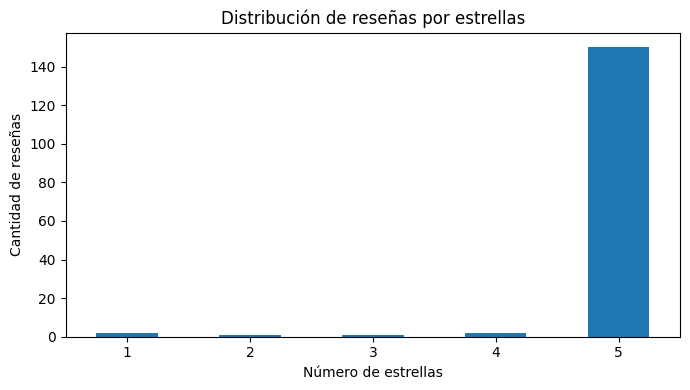

In [52]:
# Crea un gráfico de barras con la cantidad de reseñas por estrella.
tabla_estrellas["CANTIDAD"].plot(kind="bar", figsize=(7, 4))

plt.title("Distribución de reseñas por estrellas")
plt.xlabel("Número de estrellas")
plt.ylabel("Cantidad de reseñas")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [53]:
# Resume estadísticamente la variable ESTRELLAS.
df_reviews["ESTRELLAS"].describe().round(2)

count    156.00
mean       4.90
std        0.54
min        1.00
25%        5.00
50%        5.00
75%        5.00
max        5.00
Name: ESTRELLAS, dtype: float64

### Interpretación

Las reseñas presentan una valoración muy favorable: **150 de 156 registros (96,15 %) tienen cinco estrellas** y la calificación promedio alcanza **4,90 estrellas**.

Sin embargo, esta concentración también evidencia un **fuerte desbalance en la variable de calificación**. Solo seis reseñas se encuentran entre una y cuatro estrellas. En consecuencia, la base permite reconocer con claridad los atributos que los usuarios satisfechos valoran, pero ofrece una cantidad mucho menor de evidencia para explicar los factores asociados a la insatisfacción.

Este desbalance deberá tenerse presente especialmente al interpretar el análisis de sentimiento y su comparación con las estrellas.

### 4.2. Presencia de comentarios

In [54]:
# Crea etiquetas de texto sin reemplazar las variables binarias originales.
df_reviews["TIENE_COMENTARIO_TEXTO"] = (
    df_reviews["TIENE_COMENTARIO"].map({1: "Sí", 0: "No"})
)

df_reviews["TIENE_RESPUESTA_TEXTO"] = (
    df_reviews["TIENE_RESPUESTA_PROPIETARIO"].map({1: "Sí", 0: "No"})
)

# Función reutilizable para calcular cantidades y porcentajes.
def crear_tabla_frecuencia(serie, nombre_indice):
    tabla = pd.DataFrame({
        "CANTIDAD": serie.value_counts(),
        "PORCENTAJE": serie.value_counts(normalize=True).mul(100)
    }).round(2)

    tabla.index.name = nombre_indice
    return tabla

# Aplica la función a la presencia de comentarios.
tabla_comentarios = crear_tabla_frecuencia(
    df_reviews["TIENE_COMENTARIO_TEXTO"],
    "TIENE_COMENTARIO"
)

tabla_comentarios

,CANTIDAD,PORCENTAJE
TIENE_COMENTARIO,,
Sí,147,94.23
No,9,5.77


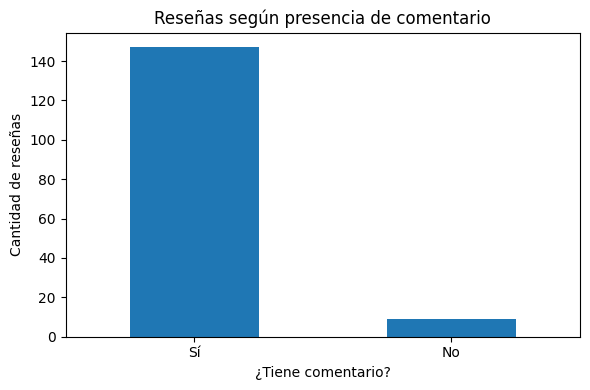

In [55]:
# Grafica las reseñas con y sin comentario.
tabla_comentarios["CANTIDAD"].plot(kind="bar", figsize=(6, 4))

plt.title("Reseñas según presencia de comentario")
plt.xlabel("¿Tiene comentario?")
plt.ylabel("Cantidad de reseñas")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretación

**147 reseñas (94,23 %) incluyen un comentario**, mientras que nueve contienen únicamente la calificación. Por tanto, la mayor parte de la muestra aporta contenido textual y existe una base suficiente para explorar términos, temas y sentimiento dentro de las opiniones.

### 4.3. Respuestas de la institución

In [56]:
# Calcula la cantidad y el porcentaje de reseñas respondidas.
tabla_respuestas = crear_tabla_frecuencia(
    df_reviews["TIENE_RESPUESTA_TEXTO"],
    "TIENE_RESPUESTA_PROPIETARIO"
)

tabla_respuestas

,CANTIDAD,PORCENTAJE
TIENE_RESPUESTA_PROPIETARIO,,
Sí,125,80.13
No,31,19.87


In [57]:
# Calcula la tasa de respuesta para cada número de estrellas.
tabla_respuesta_estrellas = (
    df_reviews
    .groupby("ESTRELLAS")["TIENE_RESPUESTA_PROPIETARIO"]
    .agg(CANTIDAD_RESEÑAS="size", RESPONDIDAS="sum")
)

tabla_respuesta_estrellas["TASA_RESPUESTA"] = (
    tabla_respuesta_estrellas["RESPONDIDAS"]
    / tabla_respuesta_estrellas["CANTIDAD_RESEÑAS"]
    * 100
).round(2)

tabla_respuesta_estrellas

,CANTIDAD_RESEÑAS,RESPONDIDAS,TASA_RESPUESTA
ESTRELLAS,,,
1,2,1,50.00
2,1,1,100.00
3,1,0,0.00
4,2,1,50.00
5,150,122,81.33


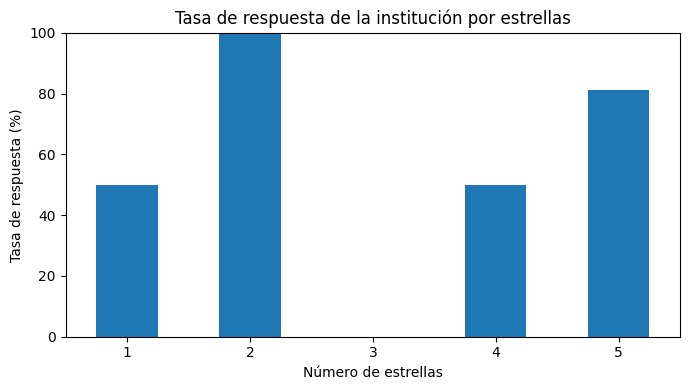

In [58]:
# Grafica la tasa de respuesta por cantidad de estrellas.
tabla_respuesta_estrellas["TASA_RESPUESTA"].plot(kind="bar", figsize=(7, 4))

plt.title("Tasa de respuesta de la institución por estrellas")
plt.xlabel("Número de estrellas")
plt.ylabel("Tasa de respuesta (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretación

La institución respondió **125 de 156 reseñas**, equivalente a una tasa general de **80,13 %**. Entre las reseñas de cinco estrellas, la tasa de respuesta es **81,33 %**.

Las tasas correspondientes a una, dos, tres y cuatro estrellas deben interpretarse con cautela debido al reducido número de observaciones en cada categoría. Aun así, la información muestra que **no todas las reseñas de baja calificación recibieron respuesta**, por lo que existe una oportunidad de priorizar este tipo de comentarios dentro de la gestión de reputación digital.

### 4.4. Longitud de los comentarios

In [59]:
# Cuenta las palabras de cada comentario.
# fillna("") evita errores en los nueve registros sin texto.
df_reviews["LONGITUD_COMENTARIO"] = (
    df_reviews["COMENTARIO"]
    .fillna("")
    .str.split()
    .str.len()
)

# Resume la distribución de la cantidad de palabras.
df_reviews["LONGITUD_COMENTARIO"].describe().round(2)

count    156.00
mean      50.89
std       53.28
min        0.00
25%       23.00
50%       39.00
75%       58.00
max      362.00
Name: LONGITUD_COMENTARIO, dtype: float64

In [60]:
# Muestra los cinco comentarios más extensos.
columnas_largos = [
    "ID_REVIEW",
    "ESTRELLAS",
    "LONGITUD_COMENTARIO"
]

df_reviews.nlargest(5, "LONGITUD_COMENTARIO")[columnas_largos]

,ID_REVIEW,ESTRELLAS,LONGITUD_COMENTARIO
49,50,5,362
21,22,5,274
38,39,5,260
96,97,5,227
92,93,2,223


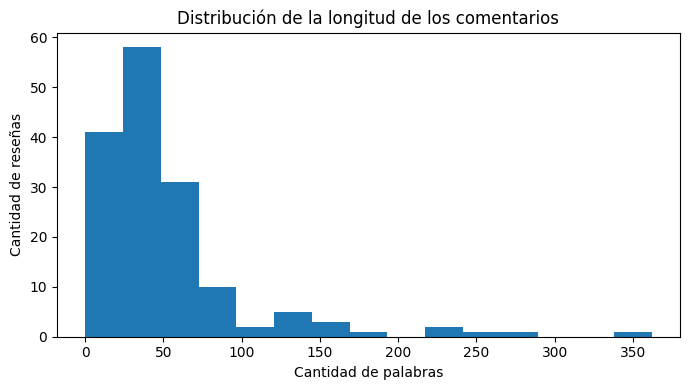

In [61]:
# Grafica la distribución de la longitud de los comentarios.
df_reviews["LONGITUD_COMENTARIO"].plot(
    kind="hist",
    bins=15,
    figsize=(7, 4)
)

plt.title("Distribución de la longitud de los comentarios")
plt.xlabel("Cantidad de palabras")
plt.ylabel("Cantidad de reseñas")
plt.tight_layout()
plt.show()

### Interpretación

Al considerar las **156 reseñas** y asignar una longitud de cero a los nueve registros sin comentario, la longitud promedio calculada es de **50,89** palabras y la mediana es de **39 palabras**. La diferencia entre ambas medidas, junto con la existencia de un comentario de **362 palabras**, muestra una distribución asimétrica: la mayoría de las reseñas son relativamente breves, pero algunos usuarios describen su experiencia con bastante detalle.

Este comportamiento favorece una estrategia combinada: los conteos de términos permiten resumir los patrones generales, mientras que la revisión cualitativa de comentarios extensos puede aportar contexto adicional.

### 4.5. Revisión de las reseñas de baja calificación

In [62]:
# Selecciona las reseñas de una a tres estrellas para una revisión cualitativa.
columnas_criticas = [
    "ID_REVIEW",
    "ESTRELLAS",
    "COMENTARIO",
    "TIENE_RESPUESTA_PROPIETARIO"
]

reseñas_criticas = df_reviews[
    df_reviews["ESTRELLAS"] <= 3
][columnas_criticas]

reseñas_criticas

,ID_REVIEW,ESTRELLAS,COMENTARIO,TIENE_RESPUESTA_PROPIETARIO
0,1,1,Poco profesional y poco confiable.,0
17,18,3,NaN,0
92,93,2,"Existe un proceso con ellos. La persuasión por iniciar el trayecto con ellos la hacen, pero ya en etapas vitales que...",1
99,100,1,"Excelente servicio al cliente mientras pagas, después de pagar no lo vale. Se pueden encontrar opciones mucho más ec...",1


### Interpretación

Las calificaciones de una a tres estrellas representan solo **4 de las 156 reseñas (2,56 %)** y una de ellas no contiene comentario. Por ello, cualquier conclusión sobre insatisfacción debe considerarse **exploratoria y cualitativa**, no generalizable.

En los pocos comentarios críticos aparecen referencias a **confianza y profesionalismo**, **percepción de menor apoyo después de la compra** y, en un caso, cuestionamientos sobre un proceso de acompañamiento administrativo más amplio. Estos hallazgos son útiles como señales de alerta para revisar expectativas y continuidad del servicio, pero el tamaño de la muestra negativa no permite afirmar que se trate de problemas generalizados.

## 5. Preparación de los comentarios para minería de texto

El análisis descriptivo utiliza todas las reseñas. A partir de esta sección se trabaja únicamente con los registros que contienen texto.

La limpieza busca reducir elementos que no aportan significado al modelamiento: se convierten los textos a minúsculas, se eliminan tildes para homogeneizar términos, se retiran enlaces y signos, y se excluyen palabras vacías en español e inglés.

Adicionalmente, se eliminan términos propios del contexto de la empresa considerados **stopwords personalizadas**, como el nombre de la institución; términos con escasa capacidad para diferenciar los temas, como `ingles`; expresiones de agradecimiento, como `gracias`; términos asociados a enlaces; y expresiones de plantilla, como `aspectos positivos`. Asimismo, se excluye `super` por su uso frecuente como intensificador y su limitada capacidad para distinguir contenidos temáticos. Esta decisión no modifica el comentario original, sino únicamente la versión procesada utilizada en el análisis de frecuencias y en el modelo NMF.


In [63]:
# Conserva únicamente las reseñas que tienen comentario.
df_texto = df_reviews[
    df_reviews["COMENTARIO"].notna()
].copy()

# Unifica las stopwords de español e inglés y elimina tildes.
stopwords = {
    unidecode(palabra.lower())
    for palabra in set(STOPWORDS_ES).union(set(STOPWORDS_EN))
}

# Términos personalizados que se retiran por ser de marca, técnicos, de plantilla o poco discriminantes para el análisis temático.
stopwords_personalizadas = {
    "ingles",
    "idiomo",
    "idiomocanada",
    "canada",
    "gracias",
    "super",
    "visa",
    "www",
    "com",
    "http",
    "https",
    "aspectos",
    "positivos",
    "feliz"
}

stopwords = stopwords.union(stopwords_personalizadas)

def limpiar_comentario(texto):
    # Convierte a minúsculas y elimina tildes.
    texto = unidecode(str(texto).lower())

    # Elimina enlaces.
    texto = re.sub(r"https?://\S+|www\.\S+", " ", texto)

    # Conserva únicamente letras y espacios.
    texto = re.sub(r"[^a-z\s]", " ", texto)

    # Retira palabras vacías y términos de menos de tres caracteres.
    palabras = [
        palabra
        for palabra in texto.split()
        if len(palabra) >= 3 and palabra not in stopwords
    ]

    return " ".join(palabras)

# Crea una nueva variable sin alterar el comentario original.
df_texto["COMENTARIO_LIMPIO"] = (
    df_texto["COMENTARIO"].apply(limpiar_comentario)
)

df_texto[
    ["COMENTARIO", "COMENTARIO_LIMPIO"]
].head()

,COMENTARIO,COMENTARIO_LIMPIO
0,Poco profesional y poco confiable.,profesional confiable
1,"Idiomo es una excelente institución, me ayudó mucho a mejorar mi inglés, tienen mucha variedad de programas que cubr...",excelente institucion ayudo mejorar variedad programas cubren necesidades alumnos asesor javier disponible dispuesto...
2,"Es un programa integral, con docentes muy competentes y retadores para desarrollarte y aprender el idioma. Desde el ...",programa integral docentes competentes retadores desarrollarte aprender idioma contacto personalizado necesidad dete...
3,"Es realmente un college de alto nivel de enseñanza .. estoy avanzando es sus clases, ya que son didácticas, se enfoc...",realmente college alto nivel ensenanza avanzando clases didacticas enfocan realmente entiendas comprendas familiaric...
4,"Super divertidas y cómodas las clases, aprendes muchas cosas y sin darte cuenta ya estás hablando, gracias a que los...",divertidas comodas clases aprendes cosas darte hablando maestros extranjeros calidad atencion carolina caycho sofia ...


In [64]:
# Verifica que ningún comentario haya quedado vacío después de la limpieza.
comentarios_vacios = (
    df_texto["COMENTARIO_LIMPIO"]
    .str.strip()
    .eq("")
    .sum()
)

print(f"Comentarios disponibles para minería de texto: {len(df_texto)}")
print(f"Comentarios vacíos después de la limpieza: {comentarios_vacios}")

Comentarios disponibles para minería de texto: 147
Comentarios vacíos después de la limpieza: 0


### Interpretación

Después de excluir los nueve registros sin comentario, quedan **147 textos** para la minería de texto. La limpieza se aplica sobre una nueva columna (`COMENTARIO_LIMPIO`), por lo que el texto original permanece disponible para cualquier revisión cualitativa posterior.

El uso conjunto de stopwords en español e inglés es pertinente porque la base contiene principalmente comentarios en español, pero también presenta expresiones y algunos textos en inglés.

## 6. Exploración de palabras y expresiones frecuentes

Antes de construir temas latentes, se realiza una exploración léxica del corpus. Los unigramas muestran qué palabras aparecen con mayor frecuencia y los bigramas ayudan a identificar expresiones recurrentes que ofrecen mayor contexto.

In [65]:
def obtener_terminos_frecuentes(textos, ngram_range=(1, 1), n=15):
    vectorizador = CountVectorizer(
        ngram_range=ngram_range,
        min_df=2,
        max_df=0.90
    )

    matriz = vectorizador.fit_transform(textos)
    frecuencias = np.asarray(matriz.sum(axis=0)).ravel()
    terminos = vectorizador.get_feature_names_out()

    tabla = (
        pd.DataFrame({
            "TERMINO": terminos,
            "FRECUENCIA": frecuencias
        })
        .sort_values("FRECUENCIA", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )

    return tabla

# Palabras más frecuentes.
tabla_unigramas = obtener_terminos_frecuentes(
    df_texto["COMENTARIO_LIMPIO"],
    ngram_range=(1, 1),
    n=15
)

tabla_unigramas

,TERMINO,FRECUENCIA
0,excelente,68
1,experiencia,55
2,clases,53
3,profesores,46
4,recomiendo,38
5,curso,32
6,proceso,28
7,mejorar,28
8,programa,27
9,aprender,27


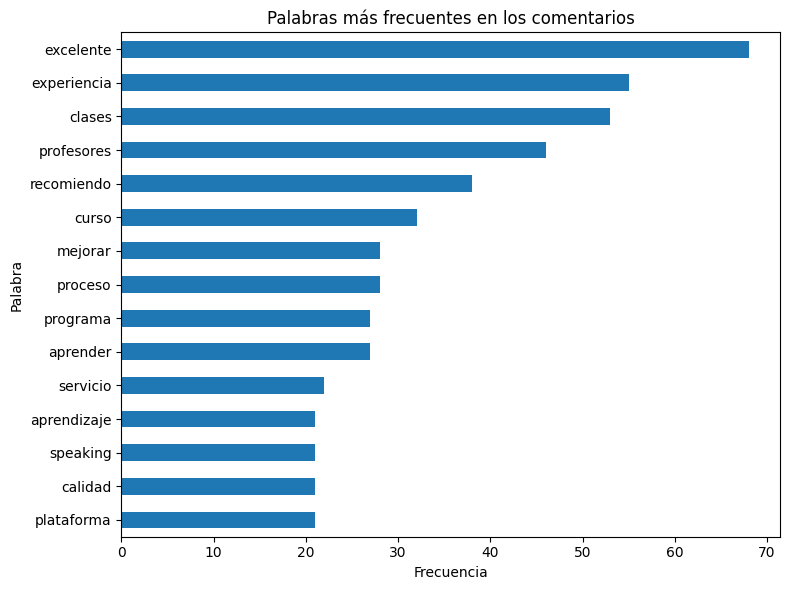

In [66]:
# Grafica las palabras más frecuentes.
tabla_unigramas.sort_values("FRECUENCIA").plot(
    kind="barh",
    x="TERMINO",
    y="FRECUENCIA",
    figsize=(8, 6),
    legend=False
)

plt.title("Palabras más frecuentes en los comentarios")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")
plt.tight_layout()
plt.show()

In [67]:
# Expresiones de dos palabras más frecuentes.
tabla_bigramas = obtener_terminos_frecuentes(
    df_texto["COMENTARIO_LIMPIO"],
    ngram_range=(2, 2),
    n=15
)

tabla_bigramas

,TERMINO,FRECUENCIA
0,calidad profesionalismo,7
1,excelente servicio,7
2,recomiendo ampliamente,7
3,profesionalismo valor,6
4,perder miedo,6
5,profesores excelentes,6
6,excelente programa,5
7,excelente experiencia,5
8,servicio cliente,5
9,profesores nativos,5


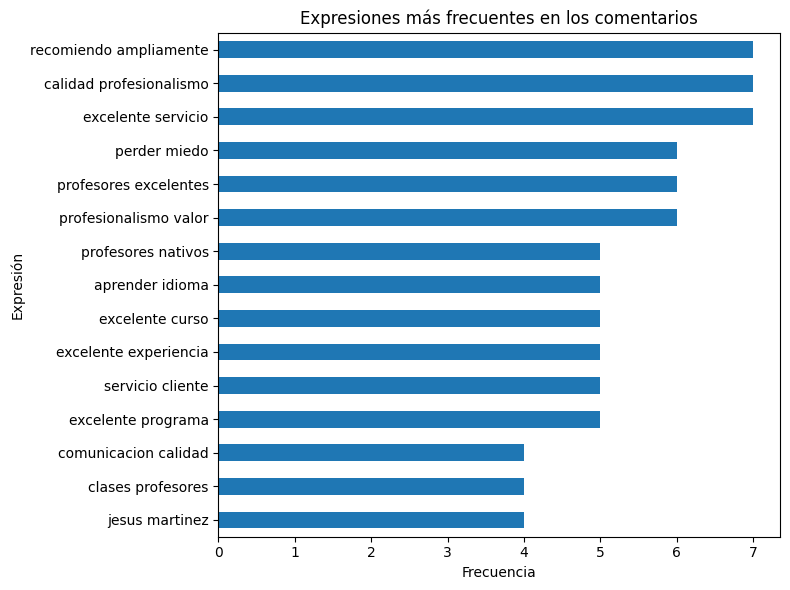

In [68]:
# Grafica las expresiones más frecuentes.
tabla_bigramas.sort_values("FRECUENCIA").plot(
    kind="barh",
    x="TERMINO",
    y="FRECUENCIA",
    figsize=(8, 6),
    legend=False
)

plt.title("Expresiones más frecuentes en los comentarios")
plt.xlabel("Frecuencia")
plt.ylabel("Expresión")
plt.tight_layout()
plt.show()

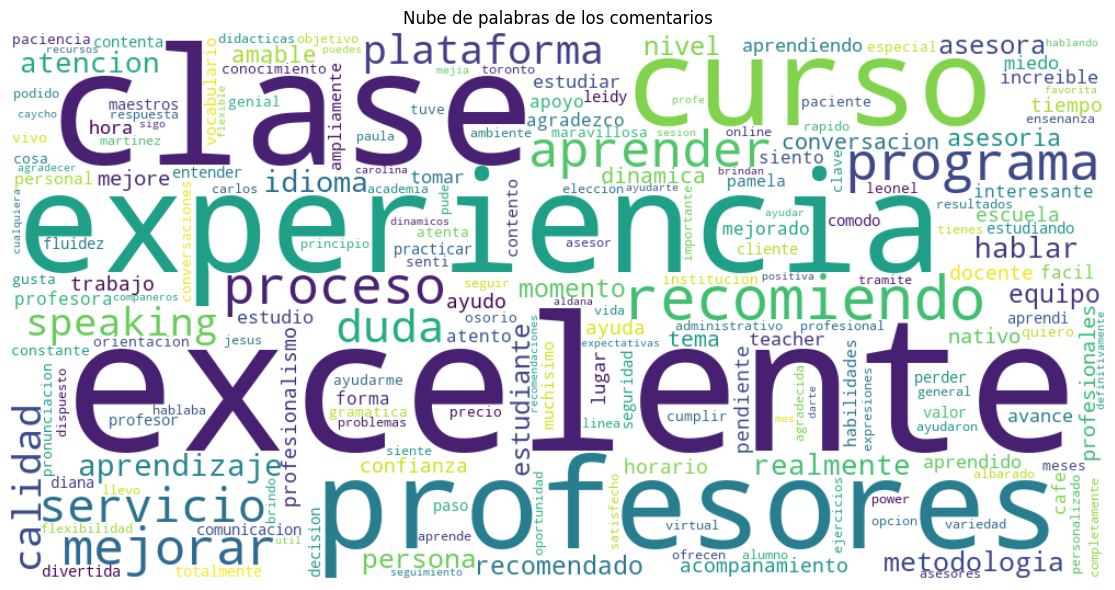

In [69]:
# Crea una nube de palabras como visualización complementaria.
texto_completo = " ".join(df_texto["COMENTARIO_LIMPIO"])

nube_palabras = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    collocations=False,
    random_state=42
).generate(texto_completo)

plt.figure(figsize=(12, 6))
plt.imshow(nube_palabras, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras de los comentarios")
plt.tight_layout()
plt.show()

### Interpretación

Después de aplicar la limpieza y las stopwords personalizadas, las palabras con mayor frecuencia son `excelente` (**68 apariciones**), `experiencia` (**55**), `clases` (**53**), `profesores` (**46**) y `recomiendo` (**38**). También destacan `curso`, `mejorar`, `proceso`, `aprender`, `programa`, `servicio`, `plataforma`, `calidad`, `aprendizaje` y `speaking`.

Los bigramas aportan mayor contexto al análisis. Entre las expresiones más frecuentes aparecen **“recomiendo ampliamente” (7)**, **“calidad profesionalismo” (7)** y **“excelente servicio” (7)**. También destacan **“profesionalismo valor” (6)**, **“profesores excelentes” (6)**, **“perder miedo” (6)** y expresiones relacionadas con el aprendizaje y el servicio, como **“aprender idioma”**, **“profesores nativos”** y **“servicio cliente”**.

En conjunto, la exploración léxica muestra que las reseñas se concentran en la **experiencia educativa**, particularmente en las clases, los profesores, el aprendizaje y los programas, junto con valoraciones relacionadas con la calidad y el servicio. La exclusión de términos generales o poco discriminantes permite que estos aspectos específicos tengan mayor presencia en el análisis. No obstante, las frecuencias por sí solas no permiten distinguir grupos temáticos completos; por ello, en la siguiente sección se aplica NMF.

## 7. Identificación de temas mediante NMF

### 7.1. Construcción de la matriz TF-IDF

NMF (*Non-negative Matrix Factorization*) es un método **no supervisado**: no requiere una variable objetivo ni categorías previamente asignadas. El modelo identifica grupos de términos que tienden a tener pesos similares dentro de los documentos.

Antes de entrenarlo, los comentarios limpios se convierten en una matriz TF-IDF. Esta representación reduce el peso de palabras muy comunes y resalta términos que ayudan a diferenciar unas reseñas de otras.

In [70]:
# Convierte los comentarios en una matriz TF-IDF.
vectorizador_tfidf = TfidfVectorizer(
    min_df=2,           # Conserva términos presentes en al menos dos comentarios.
    max_df=0.90,        # Retira términos presentes en más del 90 % de comentarios.
    ngram_range=(1, 2), # Considera palabras y bigramas.
    max_features=1000   # Limita la cantidad de características.
)

matriz_tfidf = vectorizador_tfidf.fit_transform(
    df_texto["COMENTARIO_LIMPIO"]
)

print(
    f"Matriz TF-IDF: {matriz_tfidf.shape[0]} comentarios y "
    f"{matriz_tfidf.shape[1]} términos."
)

Matriz TF-IDF: 147 comentarios y 563 términos.


### 7.2. Entrenamiento del modelo

Se especifican cinco componentes para obtener una segmentación temática suficientemente interpretable para el tamaño del corpus. El parámetro `random_state=42` permite reproducir el resultado.

In [71]:
# Crea y entrena el modelo NMF.
modelo_nmf = NMF(
    n_components=5,
    init="nndsvda",   # Inicialización estable para matrices TF-IDF.
    random_state=42,  # Permite reproducir el resultado.
    max_iter=500      # Da más iteraciones para alcanzar convergencia.
)

resultado_nmf = modelo_nmf.fit_transform(matriz_tfidf)

### 7.3. Palabras principales de cada tema

In [72]:
# Extrae las palabras con mayor peso dentro de cada tema.
def obtener_palabras_temas(modelo, vectorizador, n_palabras=10):
    terminos = vectorizador.get_feature_names_out()
    filas = []

    for numero_tema, pesos in enumerate(modelo.components_, start=1):
        posiciones = pesos.argsort()[-n_palabras:][::-1]
        palabras = [terminos[posicion] for posicion in posiciones]

        filas.append({
            "TEMA_NMF": numero_tema,
            "PALABRAS_PRINCIPALES": ", ".join(palabras)
        })

    return pd.DataFrame(filas)

# Muestra las diez expresiones principales de cada tema.
tabla_palabras_nmf = obtener_palabras_temas(
    modelo_nmf,
    vectorizador_tfidf,
    n_palabras=10
)

tabla_palabras_nmf

,TEMA_NMF,PALABRAS_PRINCIPALES
0,1,"proceso, experiencia, excelente, equipo, asesoria, recomiendo, atencion, pamela, acompanamiento, pendiente"
1,2,"excelente programa, programa, excelente, aprendizaje, curso profesores, resultados, contenido, programa excelentes, ..."
2,3,"clases, profesores, curso, plataforma, excelentes, aprendizaje, realmente, mejorar, recomiendo, profesores excelentes"
3,4,"calidad, profesionalismo, calidad profesionalismo, servicio, profesionalismo valor, valor, recomendado, excelente se..."
4,5,"aprender, lugar, lugar aprender, practicar, idioma, clases didacticas, didacticas, habilidades, definitivamente, des..."


### 7.4. Asignación e interpretación de los temas

Los nombres de los temas no son generados automáticamente por NMF. Se asignan después de revisar las palabras de mayor peso y el contenido de las reseñas más representativas de cada componente.

In [73]:
# Asigna a cada comentario el tema con la puntuación más alta.
df_texto["TEMA_NMF"] = resultado_nmf.argmax(axis=1) + 1

# Los nombres se colocan después de revisar las palabras principales.
nombres_temas_nmf = {
    1: "Experiencia, asesoría y acompañamiento",
    2: "Programa, aprendizaje y resultados",
    3: "Clases, profesores y plataforma",
    4: "Calidad, profesionalismo y servicio",
    5: "Aprendizaje y práctica del idioma"
}

df_texto["NOMBRE_TEMA_NMF"] = df_texto["TEMA_NMF"].map(
    nombres_temas_nmf
)

# Cuenta los comentarios asignados a cada tema.
tabla_conteo_nmf = (
    df_texto["NOMBRE_TEMA_NMF"]
    .value_counts()
    .rename_axis("TEMA")
    .reset_index(name="CANTIDAD")
)

tabla_conteo_nmf["PORCENTAJE"] = (
    tabla_conteo_nmf["CANTIDAD"]
    / tabla_conteo_nmf["CANTIDAD"].sum()
    * 100
).round(2)

tabla_conteo_nmf

,TEMA,CANTIDAD,PORCENTAJE
0,"Clases, profesores y plataforma",54,36.73
1,"Experiencia, asesoría y acompañamiento",41,27.89
2,"Calidad, profesionalismo y servicio",24,16.33
3,"Programa, aprendizaje y resultados",14,9.52
4,Aprendizaje y práctica del idioma,14,9.52


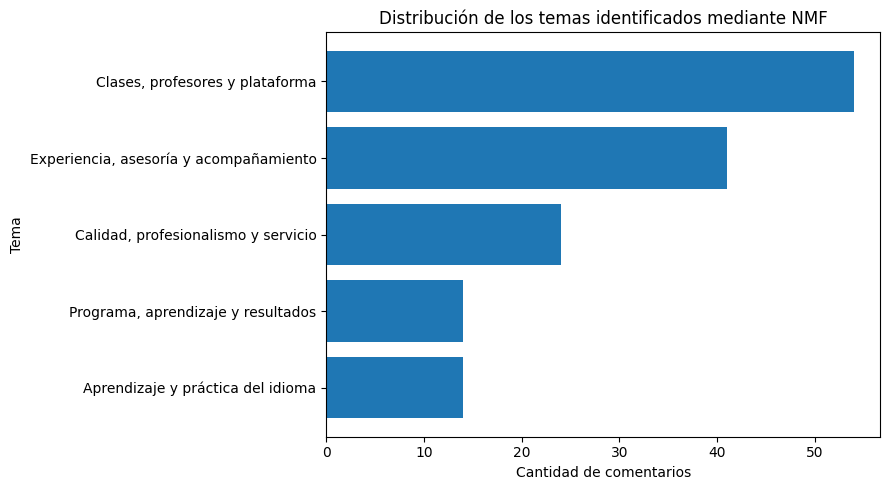

In [74]:
# Grafica la cantidad de comentarios por tema NMF.
plt.figure(figsize=(9, 5))
plt.barh(tabla_conteo_nmf["TEMA"], tabla_conteo_nmf["CANTIDAD"])

plt.title("Distribución de los temas identificados mediante NMF")
plt.xlabel("Cantidad de comentarios")
plt.ylabel("Tema")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [75]:
# Muestra los comentarios más representativos de cada tema.
filas_representativas = []

for numero_tema in range(1, modelo_nmf.n_components + 1):
    puntuaciones = resultado_nmf[:, numero_tema - 1]
    posiciones = puntuaciones.argsort()[::-1][:3]

    for posicion in posiciones:
        filas_representativas.append({
            "TEMA_NMF": numero_tema,
            "TEMA": nombres_temas_nmf[numero_tema],
            "PESO_TEMA": round(puntuaciones[posicion], 3),
            "ESTRELLAS": df_texto.iloc[posicion]["ESTRELLAS"],
            "COMENTARIO_LIMPIO": df_texto.iloc[posicion]["COMENTARIO_LIMPIO"]
        })

pd.DataFrame(filas_representativas)

,TEMA_NMF,TEMA,PESO_TEMA,ESTRELLAS,COMENTARIO_LIMPIO
0,1,"Experiencia, asesoría y acompañamiento",0.277,5,experiencia excelente equipo amable atento eficiente gestiones transmitido confianza seguridad proceso quieren exper...
1,1,"Experiencia, asesoría y acompañamiento",0.276,5,excelente proceso quedarme
2,1,"Experiencia, asesoría y acompañamiento",0.261,5,metodologia brindado experiencia mejorar fluidez acompanamiento asesoria jesus martinez proceso inscripcion couching...
3,2,"Programa, aprendizaje y resultados",0.710,5,excelente programa
4,2,"Programa, aprendizaje y resultados",0.710,5,excelente programa
5,2,"Programa, aprendizaje y resultados",0.485,5,excelente programa aprendizaje curso profesores contenido
6,3,"Clases, profesores y plataforma",0.299,5,contenta clases comodo aprender casa horario conviene ofrecen clases dial inscrita curso especializado speaking prin...
7,3,"Clases, profesores y plataforma",0.276,5,curso exelentes profesores entretenido plataforma
8,3,"Clases, profesores y plataforma",0.270,5,excelente curso recomiendo profesores profesionales evidente experiencia docencia aburrida clase virtual clases gram...
9,4,"Calidad, profesionalismo y servicio",0.518,5,excelente servicio capacidad respuesta calidad profesionalismo valor


### Interpretación

Con la preparación textual utilizada, el modelo organiza las **147 reseñas con comentario** en cinco temas:

- **Clases, profesores y plataforma:** 54 comentarios (**36,73 %**). Es el tema con mayor presencia y reúne referencias a profesores, clases, cursos, plataforma, aprendizaje y mejora.
- **Experiencia, asesoría y acompañamiento:** 41 comentarios (**27,89 %**). Agrupa menciones relacionadas con la experiencia, el proceso, el equipo, la atención, la asesoría y el acompañamiento.
- **Calidad, profesionalismo y servicio:** 24 comentarios (**16,33 %**). Reúne valoraciones vinculadas con la calidad, el profesionalismo, el servicio, el valor percibido y la recomendación.
- **Programa, aprendizaje y resultados:** 14 comentarios (**9,52 %**). Incluye referencias al programa, el aprendizaje, los contenidos y los resultados obtenidos.
- **Aprendizaje y práctica del idioma:** 14 comentarios (**9,52 %**). Se relaciona con aprender, practicar, desarrollar habilidades y participar en clases didácticas orientadas al dominio del idioma.

El principal hallazgo es que los dos temas con mayor presencia se relacionan con la **experiencia educativa concreta** y con el **acompañamiento recibido durante el proceso**. En conjunto, “Clases, profesores y plataforma” y “Experiencia, asesoría y acompañamiento” concentran aproximadamente el **64,62 %** de los comentarios analizados. Asimismo, aparecen dimensiones diferenciadas relacionadas con la calidad del servicio, las características de los programas y la práctica del idioma.

Los temas deben entenderse como **estructuras latentes interpretativas**, no como categorías verdaderas o mutuamente excluyentes. Una misma reseña puede contener elementos de varios temas, aunque el código la asigne al componente con mayor peso.

## 8. Análisis de sentimiento con un modelo preentrenado

El análisis de estrellas ofrece una señal explícita de satisfacción, pero el comentario puede contener matices que no siempre quedan reflejados en la calificación. Para complementar esa información se utiliza `pysentimiento/robertuito-sentiment-analysis`, un modelo preentrenado que clasifica los textos como **positivos, neutrales o negativos**.

La clasificación se aplica sobre el comentario original, no sobre el texto limpiado para NMF, porque los modelos de lenguaje aprovechan el contexto completo de la oración.

In [76]:
# Instala las librerías requeridas para usar el modelo preentrenado.
%pip install -q torch transformers sentencepiece

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [77]:
from transformers import pipeline

# Carga el modelo de sentimiento en español.
analizador_sentimiento = pipeline(
    task="sentiment-analysis",
    model="pysentimiento/robertuito-sentiment-analysis"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

### 8.1. Clasificación del sentimiento de los comentarios

In [78]:
# Conserva únicamente las reseñas que tienen comentario.
df_sentimiento = df_reviews[
    df_reviews["COMENTARIO"].notna()
].copy()

# Convierte los comentarios en una lista.
comentarios = df_sentimiento["COMENTARIO"].astype(str).tolist()

# Clasifica los comentarios por lotes para aprovechar mejor la memoria.
resultados_sentimiento = analizador_sentimiento(
    comentarios,
    truncation=True,
    batch_size=16
)

# Guarda la etiqueta y la confianza del modelo.
df_sentimiento["SENTIMIENTO"] = [
    resultado["label"] for resultado in resultados_sentimiento
]

df_sentimiento["CONFIANZA"] = [
    round(resultado["score"], 3) for resultado in resultados_sentimiento
]

# Traduce las etiquetas al español.
etiquetas_sentimiento = {
    "POS": "Positivo",
    "NEU": "Neutral",
    "NEG": "Negativo"
}

df_sentimiento["SENTIMIENTO"] = (
    df_sentimiento["SENTIMIENTO"].map(etiquetas_sentimiento)
)

df_sentimiento[["COMENTARIO", "SENTIMIENTO", "CONFIANZA"]].head(10)

,COMENTARIO,SENTIMIENTO,CONFIANZA
0,Poco profesional y poco confiable.,Negativo,0.903
1,"Idiomo es una excelente institución, me ayudó mucho a mejorar mi inglés, tienen mucha variedad de programas que cubr...",Positivo,0.974
2,"Es un programa integral, con docentes muy competentes y retadores para desarrollarte y aprender el idioma. Desde el ...",Positivo,0.917
3,"Es realmente un college de alto nivel de enseñanza .. estoy avanzando es sus clases, ya que son didácticas, se enfoc...",Positivo,0.979
4,"Super divertidas y cómodas las clases, aprendes muchas cosas y sin darte cuenta ya estás hablando, gracias a que los...",Positivo,0.979
5,Excelente programa. eh,Positivo,0.944
6,"¡Excelente escuela! Solo llevo dos meses con Idiomo, pero mi experiencia hasta ahora ha sido muy positiva. Me gusta ...",Positivo,0.976
7,"Me parece una academia de un nivel en calidad bastante elevado, organizados, muy buenos docentes, la metodología. Mi...",Positivo,0.974
8,"Amazing school, Native Teachers, flexible schedules! My teacher Summit the best and the account management Paula rea...",Positivo,0.971
9,"Buen programa de clases, excelentes maestros... He enriquecido mi vocabulario a nivel experto y he aprendido numeros...",Positivo,0.973


In [79]:
# Resume cantidad y porcentaje de comentarios por sentimiento.
tabla_sentimiento = pd.DataFrame({
    "CANTIDAD": df_sentimiento["SENTIMIENTO"].value_counts(),
    "PORCENTAJE": (
        df_sentimiento["SENTIMIENTO"]
        .value_counts(normalize=True)
        .mul(100)
    )
}).round(2)

tabla_sentimiento

,CANTIDAD,PORCENTAJE
SENTIMIENTO,,
Positivo,143,97.28
Negativo,2,1.36
Neutral,2,1.36


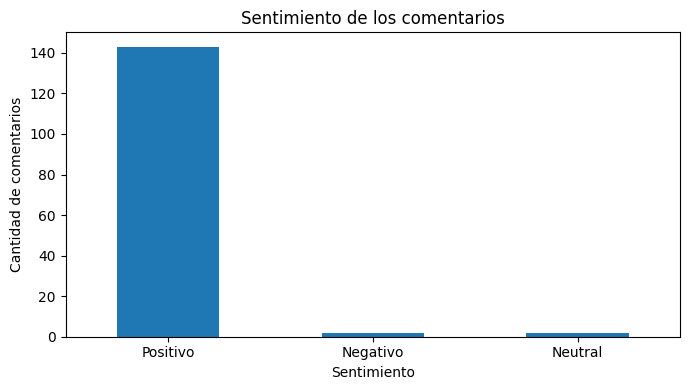

In [80]:
# Grafica la distribución del sentimiento.
tabla_sentimiento["CANTIDAD"].plot(kind="bar", figsize=(7, 4))

plt.title("Sentimiento de los comentarios")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de comentarios")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [81]:
# Genera una interpretación basada en la salida real del modelo.
from IPython.display import display, Markdown

orden_sentimientos = ["Positivo", "Neutral", "Negativo"]
resumen_sentimiento = tabla_sentimiento.reindex(
    orden_sentimientos,
    fill_value=0
)

sentimiento_principal = resumen_sentimiento["CANTIDAD"].idxmax()
cantidad_principal = int(resumen_sentimiento.loc[sentimiento_principal, "CANTIDAD"])
porcentaje_principal = resumen_sentimiento.loc[sentimiento_principal, "PORCENTAJE"]

display(Markdown(
    f"""### Interpretación

El sentimiento predominante identificado por el modelo es **{sentimiento_principal.lower()}**, con **{cantidad_principal} comentarios ({porcentaje_principal:.2f} %)**.

La clasificación textual complementa la información de las estrellas porque permite detectar matices dentro del comentario. En esta base debe interpretarse junto con el fuerte predominio de calificaciones de cinco estrellas y no como una medición independiente de satisfacción."""
))

### Interpretación

El sentimiento predominante identificado por el modelo es **positivo**, con **143 comentarios (97.28 %)**.

La clasificación textual complementa la información de las estrellas porque permite detectar matices dentro del comentario. En esta base debe interpretarse junto con el fuerte predominio de calificaciones de cinco estrellas y no como una medición independiente de satisfacción.

### 8.2. Comparación referencial entre sentimiento y estrellas

Para explorar la coherencia entre ambas fuentes de información se convierte la calificación en una categoría de sentimiento:

- 1–2 estrellas → Negativo.
- 3 estrellas → Neutral.
- 4–5 estrellas → Positivo.

Esta comparación es **referencial**. Las estrellas no constituyen una etiqueta de verdad absoluta para el contenido textual y, por tanto, la matriz de confusión no debe interpretarse como una validación formal del modelo.

Además, entre las **147 reseñas con comentario**, la referencia derivada de las estrellas contiene **144 casos positivos y 3 negativos**, sin reseñas de tres estrellas con texto. Esto genera un desbalance muy fuerte y deja a la clase neutral sin soporte en la referencia.

In [82]:
# Convierte las estrellas en una categoría de sentimiento referencial.
def clasificar_sentimiento_estrellas(estrellas):
    if estrellas <= 2:
        return "Negativo"
    elif estrellas == 3:
        return "Neutral"
    else:
        return "Positivo"

# Aplica la regla a cada reseña con comentario.
df_sentimiento["SENTIMIENTO_ESTRELLAS"] = (
    df_sentimiento["ESTRELLAS"].apply(clasificar_sentimiento_estrellas)
)

# Indica si el sentimiento del texto coincide con el derivado de las estrellas.
df_sentimiento["COINCIDE"] = (
    df_sentimiento["SENTIMIENTO"]
    == df_sentimiento["SENTIMIENTO_ESTRELLAS"]
)

porcentaje_coincidencia = df_sentimiento["COINCIDE"].mean() * 100
print(f"Coincidencia entre texto y estrellas: {porcentaje_coincidencia:.2f} %")

Coincidencia entre texto y estrellas: 97.96 %


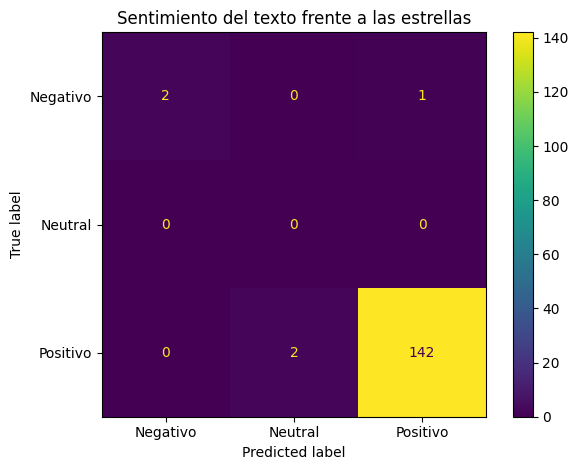

              precision    recall  f1-score   support

    Negativo       1.00      0.67      0.80         3
     Neutral       0.00      0.00      0.00         0
    Positivo       0.99      0.99      0.99       144

    accuracy                           0.98       147
   macro avg       0.66      0.55      0.60       147
weighted avg       0.99      0.98      0.99       147



In [83]:
# Construye la matriz de confusión.
clases_sentimiento = ["Negativo", "Neutral", "Positivo"]

matriz_sentimiento = confusion_matrix(
    df_sentimiento["SENTIMIENTO_ESTRELLAS"],
    df_sentimiento["SENTIMIENTO"],
    labels=clases_sentimiento
)

# Grafica la matriz.
ConfusionMatrixDisplay(
    confusion_matrix=matriz_sentimiento,
    display_labels=clases_sentimiento
).plot()

plt.title("Sentimiento del texto frente a las estrellas")
plt.tight_layout()
plt.show()

# Muestra precision, recall y F1 por categoría.
print(classification_report(
    df_sentimiento["SENTIMIENTO_ESTRELLAS"],
    df_sentimiento["SENTIMIENTO"],
    labels=clases_sentimiento,
    zero_division=0
))

In [84]:
# Muestra los casos donde el sentimiento textual y las estrellas no coinciden.
columnas_discrepancias = [
    "ID_REVIEW",
    "ESTRELLAS",
    "SENTIMIENTO_ESTRELLAS",
    "SENTIMIENTO",
    "CONFIANZA",
    "COMENTARIO"
]

discrepancias_sentimiento = df_sentimiento[
    ~df_sentimiento["COINCIDE"]
][columnas_discrepancias].sort_values(
    "CONFIANZA",
    ascending=False
)

discrepancias_sentimiento.head(15)

,ID_REVIEW,ESTRELLAS,SENTIMIENTO_ESTRELLAS,SENTIMIENTO,CONFIANZA,COMENTARIO
99,100,1,Negativo,Positivo,0.673,"Excelente servicio al cliente mientras pagas, después de pagar no lo vale. Se pueden encontrar opciones mucho más ec..."
128,129,5,Positivo,Neutral,0.623,Totalmente recomendado
26,27,5,Positivo,Neutral,0.562,"Cuando empecé en el curso realmente tenía mucha inseguridad si realmente funcionaría, sin embargo, a medida que fui ..."


### Interpretación

La **coincidencia descriptiva** entre el sentimiento del texto y la categoría derivada de las estrellas es de **97,96 %**. Se identifican **3 comentarios** en los que ambas señales difieren.

Las discrepancias son especialmente útiles para una revisión cualitativa, ya que pueden estar relacionadas con matices, ironía, brevedad del comentario, experiencias mixtas o limitaciones del modelo. Por ello, deben revisarse individualmente y no interpretarse automáticamente como observaciones críticas.

Debido al fuerte desbalance de la referencia —**144 casos positivos, 3 negativos y ningún neutral con comentario**—, las métricas de `classification_report` deben interpretarse con cautela. La comparación sirve principalmente como **diagnóstico de coherencia** entre ambas señales y no como una prueba definitiva del desempeño o precisión general del modelo.

## 9. Conclusiones

El análisis evidencia una **percepción predominantemente favorable** en la muestra de Google Reviews para la institución EdTech. De las 156 reseñas disponibles, 150 tienen cinco estrellas, equivalente al **96,15 %**, y la calificación promedio es de **4,90 estrellas**. Esta concentración indica una percepción predominantemente favorable entre quienes publicaron una reseña, aunque también limita la cantidad de evidencia disponible para estudiar la insatisfacción.

La base presenta una buena disponibilidad de información textual: **147 reseñas (94,23 %)** contienen comentario. Después de aplicar la limpieza y las stopwords personalizadas, el vocabulario más recurrente incluye términos como `excelente`, `experiencia`, `clases`, `profesores` y `recomiendo`. Los bigramas, entre ellos **“recomiendo ampliamente”**, **“calidad profesionalismo”**, **“excelente servicio”** y **“profesores excelentes”**, muestran que el discurso combina referencias a la experiencia educativa con valoraciones sobre la calidad y el servicio.

El modelamiento NMF muestra que el tema con **mayor presencia entre los comentarios asignados** es **“Clases, profesores y plataforma”**, con **54 comentarios (36,73 %)**. Le sigue **“Experiencia, asesoría y acompañamiento”**, con **41 comentarios (27,89 %)**. En conjunto, ambos temas concentran aproximadamente el **64,62 %** de los comentarios analizados, lo que sugiere que la percepción del servicio se construye principalmente a partir de la experiencia educativa concreta y del acompañamiento recibido durante el proceso.

La gestión de reputación digital presenta una cobertura importante, con **125 de 156 reseñas respondidas (80,13 %)**. Sin embargo, no todas las reseñas de baja calificación recibieron respuesta. Dado que los casos críticos son escasos, cada uno puede tener un peso reputacional proporcionalmente mayor y merece una revisión individual.

Los pocos comentarios de baja calificación señalan cuestiones relacionadas con confianza, profesionalismo, continuidad del apoyo y expectativas de servicio. Debido a que las reseñas de una a tres estrellas representan solo **2,56 %** de la muestra, estos aspectos deben tratarse como señales cualitativas para investigación interna y no como problemas generalizados.

Finalmente, el análisis de sentimiento complementa las estrellas al permitir revisar el tono del texto y detectar posibles discrepancias entre una calificación y el contenido escrito. No obstante, el fuerte desbalance hacia las valoraciones positivas implica que la comparación con las estrellas debe utilizarse como herramienta exploratoria y no como una evaluación formal del modelo.

## 10. Recomendaciones

1. **Consolidar los atributos educativos mejor valorados.** Las clases, los profesores, la plataforma y el aprendizaje conforman el tema con mayor presencia entre los comentarios analizados. Conviene mantener el seguimiento de estos componentes como indicadores centrales de la experiencia educativa.

2. **Fortalecer la continuidad del acompañamiento.** El segundo tema con mayor presencia se relaciona con la experiencia, la asesoría y el acompañamiento durante el proceso. La institución puede estandarizar puntos de contacto antes, durante y después de la incorporación del estudiante para reducir diferencias entre expectativas y experiencia real.

3. **Priorizar las reseñas críticas dentro del protocolo de respuesta.** Aunque la tasa general de respuesta es de 80,13 %, no todas las calificaciones bajas fueron atendidas. Se recomienda establecer una alerta específica para reseñas de una a tres estrellas y responderlas con orientación a solución, seguimiento y cierre.

4. **Revisar sistemáticamente las discrepancias entre estrellas y sentimiento textual.** Los tres casos detectados deben analizarse individualmente, ya que una discrepancia puede originarse en ironía, brevedad, lenguaje mixto o limitaciones del modelo. Por ello, no debe interpretarse automáticamente como una observación crítica.

5. **Utilizar los temas identificados como dimensiones de seguimiento.** Los resultados del NMF pueden servir como base para un tablero de monitoreo organizado en cinco dimensiones: clases, profesores y plataforma; experiencia, asesoría y acompañamiento; calidad, profesionalismo y servicio; programa, aprendizaje y resultados; y aprendizaje y práctica del idioma.

6. **Mejorar la dimensión temporal de futuras bases.** `TIEMPO_REVIEW` contiene referencias relativas como “hace un mes” o “hace tres meses”. Para estudiar tendencias, cambios en satisfacción o efectos de acciones de mejora, sería preferible disponer de una fecha exacta de publicación de cada reseña.